# FAERS Pharmacovigilance Analysis

This project analyzes FAERS adverse event reports to explore relationships between drugs and reported outcomes. It uses Python for data cleaning and feature engineering, and SQL for aggregation and ranking of drugs based on reported severity scores. The analysis focuses on identifying drugs most frequently associated with higher reported severity in adverse event data.

## Exploratory data analysis of FAERS dataset

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv(r"C:\Users\evrik\Downloads\faers.csv", nrows=10000)

In [6]:
df.shape

(10000, 30)

In [7]:
df.head()

,report_id,receive_date,year,month,quarter,serious,serious_flags,is_fatal,is_hospitalized,is_life_threat,...,manufacturer,pharm_class,num_drugs,drug_count_category,patient_age_years,age_group,patient_sex,patient_weight_kg,country,report_age_days
0,10004718,2015-02-11,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Glaxosmithkline Llc,Unknown,7,Polypharmacy(6+),64.0,Middle-Aged(41-65),Female,NaN,US,4063
1,10004926,2015-02-13,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Bayer Healthcare Pharmaceuticals Inc.,Progestin [EPC]; Progestin-containing Intraute...,1,Single,20.0,Adult(19-40),Female,54.0,US,4061
2,10005223,2015-02-19,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Cordavis Limited; Abbvie Inc.,Unknown,14,Polypharmacy(6+),60.0,Middle-Aged(41-65),Female,NaN,US,4055
3,10005378,2015-02-17,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Unknown,Unknown,34,Polypharmacy(6+),20.0,Adult(19-40),Female,NaN,BR,4057
4,10005980,2015-02-21,2015,2,2015Q1,Yes,NaN,False,False,False,...,Live Betr Llc; American Sales Company; Little ...,Unknown,7,Polypharmacy(6+),NaN,Unknown,Female,NaN,GB,4053


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   report_id            10000 non-null  int64  
 1   receive_date         10000 non-null  str    
 2   year                 10000 non-null  int64  
 3   month                10000 non-null  int64  
 4   quarter              10000 non-null  str    
 5   serious              10000 non-null  str    
 6   serious_flags        6151 non-null   str    
 7   is_fatal             10000 non-null  bool   
 8   is_hospitalized      10000 non-null  bool   
 9   is_life_threat       10000 non-null  bool   
 10  is_disabling         10000 non-null  bool   
 11  reactions            10000 non-null  str    
 12  primary_reaction     10000 non-null  str    
 13  reaction_outcomes    10000 non-null  str    
 14  patient_recovered    10000 non-null  bool   
 15  num_reactions        10000 non-null  int64  
 16

In [9]:
df.columns

Index(['report_id', 'receive_date', 'year', 'month', 'quarter', 'serious',
       'serious_flags', 'is_fatal', 'is_hospitalized', 'is_life_threat',
       'is_disabling', 'reactions', 'primary_reaction', 'reaction_outcomes',
       'patient_recovered', 'num_reactions', 'suspect_drug', 'brand_name',
       'drug_route', 'drug_indication', 'manufacturer', 'pharm_class',
       'num_drugs', 'drug_count_category', 'patient_age_years', 'age_group',
       'patient_sex', 'patient_weight_kg', 'country', 'report_age_days'],
      dtype='str')

In [10]:
df['suspect_drug'].value_counts().head(10)

suspect_drug
AVANDIA                               8611
AVANDAMET                              385
ATORVASTATIN CALCIUM                    95
AVANDARYL                               60
ECULIZUMAB                              50
DROSPIRENONE AND ETHINYL ESTRADIOL      43
ETANERCEPT                              34
ADALIMUMAB                              31
LEVONORGESTREL                          23
PREGABALIN                              18
Name: count, dtype: int64

### EDA Insight 1: Reporting frequency is not equal to risk

1. Observation

The most frequently reported drugs include:
diabetes medications (e.g. Avandia)
biologics (e.g. Adalimumab, Etanercept)
cardiovascular and hormonal drugs

2. Interpretation

These drugs are not necessarily the “most dangerous,” but 
they are widely used in chronic conditions and in high-risk patient populations
that are under strong pharmacovigilance surveillance

3. Key conclusion

Raw FAERS counts reflect reporting frequency, not true risk levels.


In [11]:
df_clean = df[['suspect_drug', 'reactions']].dropna()

In [12]:
top_pairs = (
    df_clean.groupby(['suspect_drug', 'reactions'])
    .size()
    .sort_values(ascending=False)
    .head(15)
)

top_pairs

suspect_drug          reactions                                        
AVANDIA               Myocardial infarction                                2415
                      Cerebrovascular accident                             1437
                      Acute myocardial infarction                           517
                      Coronary arterial stent insertion                     268
                      Coronary artery bypass                                188
                      Myocardial infarction; Cardiac failure congestive     179
                      Myocardial infarction; Coronary artery disease        177
                      Coronary artery disease; Myocardial infarction        157
                      Cardiac failure congestive; Myocardial infarction     140
                      Vascular graft                                         88
                      Myocardial ischaemia                                   85
AVANDAMET             Myocardial infarction     

### EDA Insight 2: Drug–reaction associations are influenced by confounding and reporting bias, limiting causal interpretation 

The FAERS dataset shows strong clustering of cardiovascular-related events associated with Avandia, including myocardial infarction and stroke-related outcomes. However, these signals likely reflect a combination of confounding by indication (diabetic population baseline risk), historical pharmacovigilance attention, and reporting bias, rather than direct causal inference.

In [13]:
df['reaction_outcomes'].value_counts()

reaction_outcomes
Unknown                                                 4534
Recovered                                               2785
Unknown; Recovered                                      2070
Unknown; Not Recovered                                   207
Not Recovered                                            148
Unknown; Not Recovered; Recovered                         68
Unknown; Recovering                                       37
Not Recovered; Recovered                                  32
Recovering                                                28
Unknown; Recovered; Recovering                            18
Recovered; Recovering                                     15
Unknown; Not Recovered; Recovered; Recovering             14
Unknown; Not Recovered; Recovering                        12
Fatal                                                      9
Not Recovered; Recovered; Recovering                       6
Unknown; Recovered; Fatal                                  5
Not Re

### EDA Insight 3: Outcome severity signals are limited by high uncertainty and multi-label reporting structure

The reaction_outcomes field contains multiple labels per record, indicating that outcomes are not mutually exclusive.
The majority of entries include “Unknown”, reducing interpretability of severity patterns.
Fatal outcomes are present but rare relative to total reports.
This structure limits direct ranking of drugs by severity without further data preprocessing.

## Data Cleaning and Standardization

In [14]:
df.isnull().sum().sort_values(ascending=False)

patient_weight_kg      9369
serious_flags          3849
patient_age_years      3709
month                     0
year                      0
report_id                 0
serious                   0
is_fatal                  0
is_hospitalized           0
is_life_threat            0
is_disabling              0
reactions                 0
quarter                   0
receive_date              0
reaction_outcomes         0
primary_reaction          0
patient_recovered         0
num_reactions             0
drug_route                0
drug_indication           0
suspect_drug              0
brand_name                0
pharm_class               0
manufacturer              0
drug_count_category       0
num_drugs                 0
age_group                 0
patient_sex               0
country                   0
report_age_days           0
dtype: int64

### Missing Data Assessment

Most core analytical variables (drug names, reactions, severity indicators, and outcomes) contain no missing values, suggesting the dataset is suitable for downstream comparative analysis. Missingness is concentrated in patient-level clinical metadata such as weight and age, which is common in spontaneous adverse event reporting systems.

In [15]:
text_cols = [
    'suspect_drug',
    'reactions',
    'reaction_outcomes',
    'patient_sex',
    'country'
]

for col in text_cols:
    df[col] = df[col].astype(str).str.upper().str.strip()

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df[['is_fatal', 'is_hospitalized', 'is_life_threat', 'serious']].head()

,is_fatal,is_hospitalized,is_life_threat,serious
0,False,True,False,Yes
1,False,True,False,Yes
2,False,True,False,Yes
3,False,True,False,Yes
4,False,False,False,Yes


Severity flags are already engineered, which lets us begin comparative severity analysis faster. Let's optimise data to gain the fatality rate approximation.

In [18]:
fatal_rate = (
    df.groupby('suspect_drug')['is_fatal']
    .mean()
    .sort_values(ascending=False)
)

fatal_rate.head(10)

suspect_drug
ACETAMINOPHEN, GUAIFENESIN, AND PHENYLEPHRINE HYDROCHLORIDE; ACETAMINOPHEN    1.0
[NO SUSPECT PRODUCT]                                                          1.0
ACLASTA                                                                       1.0
SODIUM CHLORIDE; SODIUM CHLORIDE TABLET; SODIUM CHLORIDE TABLETS              1.0
THALIDOMIDE                                                                   1.0
SITAGLIPTIN                                                                   1.0
PRIVIGEN                                                                      1.0
REDIMUNE                                                                      1.0
OXYCODONE HYDROCHLORIDE AND ACETAMINOPHEN                                     1.0
PALLADON INJEKT                                                               1.0
Name: is_fatal, dtype: float64

### Methodological Insight 4

Fatality rates computed without minimum sample thresholds are highly unstable and dominated by low-frequency drugs, leading to misleading extreme values. We must reconsider the metric as "Fatal proportion among drugs with meaningful sample size".

In [19]:
drug_counts = df['suspect_drug'].value_counts()

valid_drugs = drug_counts[drug_counts >= 10].index

df_filtered = df[df['suspect_drug'].isin(valid_drugs)]

In [20]:
fatal_rate = (
    df_filtered.groupby('suspect_drug')['is_fatal']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

fatal_rate

suspect_drug
AMBRISENTAN                           0.312500
LENALIDOMIDE                          0.230769
TREPROSTINIL                          0.200000
ECULIZUMAB                            0.160000
AVANDARYL                             0.133333
AVANDIA                               0.114621
AVANDAMET                             0.098701
ADALIMUMAB                            0.064516
PREGABALIN                            0.055556
DROSPIRENONE AND ETHINYL ESTRADIOL    0.000000
Name: is_fatal, dtype: float64

### Insight 5a : Severity proportions vary across drugs but are strongly influenced by underlying patient populations and treatment context

Key observation:

Fatal report proportions differ significantly between drugs, ranging from near zero to over 30%.

Interpretation:

Higher severity proportions are often associated with drugs used in serious or life-threatening conditions, while lower proportions reflect medications prescribed to healthier populations.

Key conclusion:

Fatality rates in FAERS cannot be interpreted as direct drug toxicity measures without adjusting for indication severity and patient baseline risk.

In [21]:
df['severity_score'] = (
    df['is_fatal'].astype(int) * 3 +
    df['is_life_threat'].astype(int) * 2 +
    df['is_hospitalized'].astype(int) * 1
)

In [22]:
df['severity_score'].value_counts().sort_index()

severity_score
0    3886
1    4943
2      11
3     735
4     417
5       3
6       5
Name: count, dtype: int64

In [23]:
drug_severity = (
    df.groupby('suspect_drug')['severity_score']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

drug_severity

suspect_drug
PRIVIGEN                                                                                       6.000000
REDIMUNE                                                                                       6.000000
HEPARIN SODIUM                                                                                 4.500000
SITAGLIPTIN                                                                                    4.000000
[NO SUSPECT PRODUCT]                                                                           4.000000
TRETINOIN                                                                                      4.000000
CETUXIMAB                                                                                      4.000000
ACETAMINOPHEN, GUAIFENESIN, AND PHENYLEPHRINE HYDROCHLORIDE; ACETAMINOPHEN                     4.000000
ACETAMINOPHEN                                                                                  4.000000
LEUPROLIDE ACETATE                                 

In [24]:
drug_counts = df['suspect_drug'].value_counts()

In [25]:
valid_drugs = drug_counts[drug_counts >= 10].index
df_valid = df[df['suspect_drug'].isin(valid_drugs)]

In [26]:
drug_severity_clean = (
    df_valid.groupby('suspect_drug')['severity_score']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

drug_severity_clean

suspect_drug
AMBRISENTAN                           1.687500
TREPROSTINIL                          1.333333
LENALIDOMIDE                          1.230769
AVANDARYL                             1.183333
AVANDAMET                             1.049351
LEVONORGESTREL                        0.956522
ECULIZUMAB                            0.940000
ADALIMUMAB                            0.935484
AVANDIA                               0.882592
DROSPIRENONE AND ETHINYL ESTRADIOL    0.720930
TERIFLUNOMIDE                         0.714286
INFLIXIMAB                            0.500000
PREGABALIN                            0.444444
DIMETHYL FUMARATE                     0.307692
ETANERCEPT                            0.294118
Name: severity_score, dtype: float64

### Insight 5b : Composite severity scores reveal meaningful variation across drugs, but are strongly influenced by treatment context and underlying disease severity

Observation:

A normalized severity score combining fatal, life-threatening, and hospitalization flags shows clear differences across drugs.

Interpretation:

Higher severity scores are primarily associated with drugs used in serious or advanced disease populations, while lower scores correspond to medications used in broader or less acute clinical settings.

Key conclusion:

Composite severity scoring improves comparability across drugs, but does not isolate drug toxicity from underlying patient disease severity and reporting bias.

1. Highest severity group :
Ambrisentan (1.69)
Treprostinil (1.33)
Lenalidomide (1.23)

These are drugs used in serious diseases such as pulmonary hypertension, oncology and other advanced conditions

So severity is driven by patient condition, not just drug effect

2. Mid-severity group :
Avandia (~0.88)
Eculizumab (~0.94)
Adalimumab (~0.93)

These are chronic immune/metabolic therapies or long-term treatments on populations

3. Lower severity group :
Etanercept (0.29)
Dimethyl fumarate (0.30)
Pregabalin (0.44)

These reflect broader use populations or more outpatient treatment contexts.

# Severity Scores by number of reports

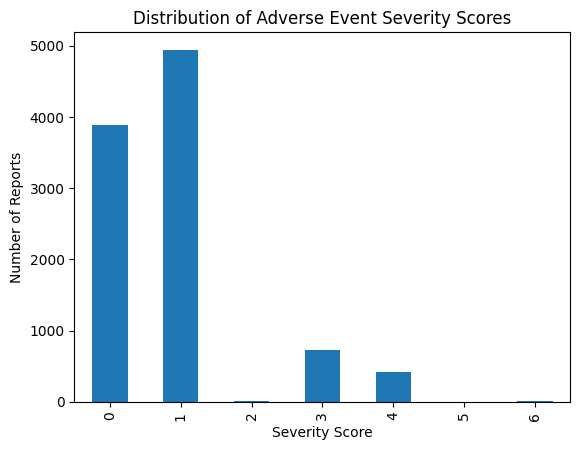

In [27]:
import matplotlib.pyplot as plt

df['severity_score'].value_counts().sort_index().plot(kind='bar')

plt.xlabel("Severity Score")
plt.ylabel("Number of Reports")
plt.title("Distribution of Adverse Event Severity Scores")

plt.show()

### Chart Interpretation

Severity scores combine hospitalization (1), life-threatening (2), and fatal outcome (3) flags into a single weighted metric. The distribution shows that most adverse event reports are low severity, while highly severe multi-flag cases occur much less frequently.

In [ ]:
df_clean = df[['suspect_drug','severity_score','is_fatal','is_hospitalized','is_life_threat','serious','patient_age_years','age_group','patient_sex','country']]
df_clean.to_csv("clean_faers_sql.csv", index=False)

In [ ]:
df_clean.to_csv("clean_faers_sql.csv", index=False)

## Transition to SQL Analysis

After completing the initial exploratory data analysis in Python, the dataset was exported in a structured and cleaned format to enable relational querying. SQL was then used to aggregate, rank, and compare drugs based on severity-related metrics, allowing for more efficient large-scale grouping and analytical operations that are less practical in Python alone.

In [ ]:
import pandas as pd

df_sql = pd.read_csv("TOPDRUGSBYSEVERITY.csv")
df_sql.head()

In [ ]:
import matplotlib.pyplot as plt

df_sql.sort_values("avg_severity").plot(
    kind="barh",
    x="suspect_drug",
    y="avg_severity"
)

plt.xlabel("Average Severity Score")
plt.ylabel("Pharmaceutical Drug")
plt.title("Top Drugs by Adverse Event Severity (SQL-derived)")
plt.show()

### Chart Interpretation

This chart shows the distribution of average adverse event severity across the top reported drugs (SQL-derived). Higher values indicate drugs more frequently associated with severe outcomes in reported cases, though results reflect reporting patterns rather than direct causality.

In [34]:
import pandas as pd

outcome_counts = pd.DataFrame({
    'Outcome': ['Fatal', 'Life-Threatening', 'Hospitalized'],
    'Count': [
        df['is_fatal'].sum(),
        df['is_life_threat'].sum(),
        df['is_hospitalized'].sum()
    ]
})

outcome_counts

,Outcome,Count
0,Fatal,1133
1,Life-Threatening,46
2,Hospitalized,5392


## Severity vs Outcome Discrepancy in FAERS Reports

In [36]:
outcome_counts.to_csv("powerbi_outcomes3.csv", index=False)

In [37]:
df_long = pd.DataFrame({
    "suspect_drug": df["suspect_drug"],
    "Fatal": df["is_fatal"],
    "Life_Threatening": df["is_life_threat"],
    "Hospitalized": df["is_hospitalized"]
})

In [38]:
df_long = df_long.melt(
    id_vars="suspect_drug",
    var_name="Outcome",
    value_name="Count"
)

In [39]:
df_drug_outcome = df_long.groupby(["suspect_drug", "Outcome"]).sum().reset_index()

In [40]:
df_drug_outcome.to_csv("drug_outcome_pbi.csv", index=False)

In [41]:
df["age_group"] = pd.cut(
    df["patient_age_years"],
    bins=[0, 18, 35, 50, 65, 120],
    labels=["0-18", "19-35", "36-50", "51-65", "65+"]
)

In [43]:
df_age = pd.DataFrame({
    "age_group": df["age_group"],
    "Fatal": df["is_fatal"],
    "Life_Threatening": df["is_life_threat"],
    "Hospitalized": df["is_hospitalized"]
})

df_age = df_age.melt(
    id_vars="age_group",
    var_name="Outcome",
    value_name="Count"
)

df_age_outcome = df_age.groupby(["age_group", "Outcome"]).sum().reset_index()

df_age_outcome.to_csv("age_outcome_pbi2.csv", index=False)